# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset. 

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [ ]:
def summarise(amounts, threshold):
    above_threshold = []
    total = 0
    for amount in amounts:
        total += amount
        if amount > threshold:
            above_threshold.append(amount)

    above_threshold.sort(reverse=True)

    mean = total / len(amounts)  
    
    summary = {
        'above_threshold': above_threshold,
        'mean': mean,
        'count_above': len(above_threshold)
}
    return summary

import pandas as pd

df = pd.read_csv('transactions.csv')
df.head()
amounts = df['amount'].tolist()
result = summarise( amounts, 500)
print(result)


{'above_threshold': [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54, 11471.08, 11371.61, 11234.88, 11199.06, 11195.5, 11101.87, 11073.38, 11069.15, 11007.74, 10905.49, 10864.93, 10713.45, 10491.16, 10380.89, 10359.9, 10312.18, 10252.55, 10151.58, 10150.55, 10095.57, 9796.81, 9794.37, 9783.26, 9764.67, 9716.4, 9612.35, 9608.31, 9600.26, 9593.46, 9568.04, 9492.12, 9468.63, 9421.41, 9420.5, 9416.27, 9376.75, 9323.98, 9311.32, 9244.25, 9211.58, 9126.68, 9093.21, 9051.72, 9026.74, 9016.71, 8991.0, 8891.44, 8880.77, 8858.52, 8828.05, 8807.32, 8786.62, 8769.03, 8713.76, 8698.26, 8687.37, 8678.88, 8671.19, 8657.93, 8651.19, 8649.46, 8643.98, 8628.76, 8604.56, 8600.0, 8591.48, 8535.93, 8504.49, 8465.53, 8427.74, 8426.91, 8375.23, 8358.33, 8317.36, 8290.01, 8255.59, 8217.94, 8211.15, 8191.41, 8187.97, 8173.21, 8154.55, 8151.36, 8089.08, 8081.51, 8077.92, 8054.42, 8021.97, 8015.36, 8010.49, 7982.2, 7973.71, 7950.58, 7946.57, 7941.33, 7901.92, 78

---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [8]:
import numpy as np
import pandas as pd
df = pd.read_csv('transactions.csv')
amounts = df['amount'].tolist()
print("Mean:", np.mean(amounts))
print("Median:", np.median(amounts))
print("Std:", np.std(amounts))
print("10th Percentile:", np.percentile(amounts, 10))
print("90th Percentile:", np.percentile(amounts, 90))

mean = np.mean(amounts)
std = np.std(amounts)
outliers_mask = np.abs(amounts - mean) > 2 * std
print("Outliers:", outliers_mask)

Mean: 1253.0228844667695
Median: 433.385
Std: 1989.756920338982
10th Percentile: 88.25
90th Percentile: 4024.015
Outliers: [False False False ... False False False]


---
## Q3 — Pandas: Load & Explore `[15 pts]`
1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.

In [8]:
import pandas as pd

df = pd.read_csv("transactions.csv")

# Shape of the DataFrame
print("Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Parse date column as datetime
df["date"] = pd.to_datetime(df["datetime"])

# Add month column
df["month"] = df["date"].dt.month

# Statistical summary for numeric columns only
print("\nNumeric Summary:")
print(df.describe())

# Unique city values
print("\nNumber of Unique Cities:")
print(df["city"].nunique())

print("\nCity Values:")
print(df["city"].unique())

# Unique category values
print("\nNumber of Unique Categories:")
print(df["category"].nunique())

print("\nCategory Values:")
print(df["category"].unique())

Shape:
(5176, 9)

Data Types:
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

Missing Values:
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64

Numeric Summary:
             amount     cashback                           date        month
count   5176.000000  4918.000000                           5176  5176.000000
mean    1253.022884    29.513211  2024-03-30 18:06:04.610703360     3.455564
min       10.000000     0.000000            2024-01-01 03:29:50     1.000000
25%      173.882500     1.070000     2024-02-16 03:28:55.500000     2.000000
50%      433.385000     6.565000     2024-03-30 01:10:56.500000     3.000000
75%     1251.317500    21.355000  2024-05-14 02:21:02.750000128     5.000000
max    14205.880000  2440.530000            2

# Q4 - Pandas: Filter & Transform (20 Points)

In this task, we perform data filtering, feature engineering, and missing value handling using Pandas.

### Objectives
1. Filter approved transactions and calculate their percentage of the total dataset.
2. Compute the cashback rate as:
   cashback_rate = cashback / amount
3. Create a boolean flag `is_suspicious` for transactions where cashback_rate exceeds 10%.
4. Fill missing cashback values using the median cashback of the corresponding category.
5. Create a `spend_tier` column:
   - Low: amount < 500
   - Mid: 500 ≤ amount ≤ 2000
   - High: amount > 2000
   

In [ ]:
import pandas as pd
df = pd.read_csv("transactions.csv")

# Filter approved transactions only
approved_df = df[df["status"] == "approved"]

percentage_approved = (len(approved_df) / len(df)) * 100

print(f"Approved Transactions: {percentage_approved:.2f}%")

# Cashback rate and suspicious flag
df["cashback_rate"] = df["cashback"] / df["amount"]

df["suspicious"] = df["cashback_rate"] > 0.10

# Fill missing cashback with per-category median
df["cashback"] = df["cashback"].fillna(
    df.groupby("category")["cashback"].transform("median")
)

# Spend tier using pd.cut
df["spend_tier"] = pd.cut(
    df["amount"],
    bins=[-float("inf"), 500, 2000, float("inf")],
    labels=["low", "mid", "high"],
    right=False
)

# Display results
print(df[["amount", "cashback", "cashback_rate", "suspicious", "spend_tier"]].head())

Approved Transactions: 88.97%
    amount  cashback  cashback_rate  suspicious spend_tier
0  1152.59    28.820       0.025005       False        mid
1    10.00     0.270       0.027000       False        low
2   926.70    10.230       0.011039       False        mid
3   137.71     3.260       0.023673       False        low
4  7001.18    97.165            NaN       False       high


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [15]:
import pandas as pd
df = pd.read_csv("transactions.csv")



# Category statistics

category_stats = (
    df.groupby("category")
      .agg(
          total_spend=("amount", "sum"),
          transaction_count=("amount", "count"),
          avg_transaction_size=("amount", "mean")
      )
)

# Decline rate
decline_rate = (
    df.groupby("category")["status"]
      .apply(lambda x: (x == "declined").mean())
)

category_stats["decline_rate"] = decline_rate

category_stats = category_stats.sort_values(
    by="total_spend",
    ascending=False
)

print("Category Stats:")
print(category_stats)

merchant_spend = (
    df.groupby(["city", "merchant"])["amount"]
      .sum()
      .reset_index(name="total_spend")
)

top3_merchants = (
    merchant_spend
    .sort_values(
        ["city", "total_spend"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(3)
)

print("\nTop 3 Merchants per City:")
print(top3_merchants)

df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month

pivot_table = pd.pivot_table(
    df,
    values="amount",
    index="month",
    columns="category",
    aggfunc="mean"
)

print("\nmonth × Category Pivot Table:")
print(pivot_table)

Category Stats:
               total_spend  transaction_count  avg_transaction_size  \
category                                                              
Travel          2213273.63                444           4984.850518   
Electronics     1722710.26                384           4486.224635   
Shopping        1031848.97                651           1585.021459   
Healthcare       438697.56                420           1044.518000   
Dining           371893.93                768            484.236888   
Utilities        290547.44                390            744.993436   
Groceries        195293.44                905            215.793856   
Entertainment    153913.21                527            292.055427   
Fuel              67468.01                687             98.206710   

               decline_rate  
category                     
Travel             0.340090  
Electronics        0.377604  
Shopping           0.188940  
Healthcare         0.061905  
Dining             0.0

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


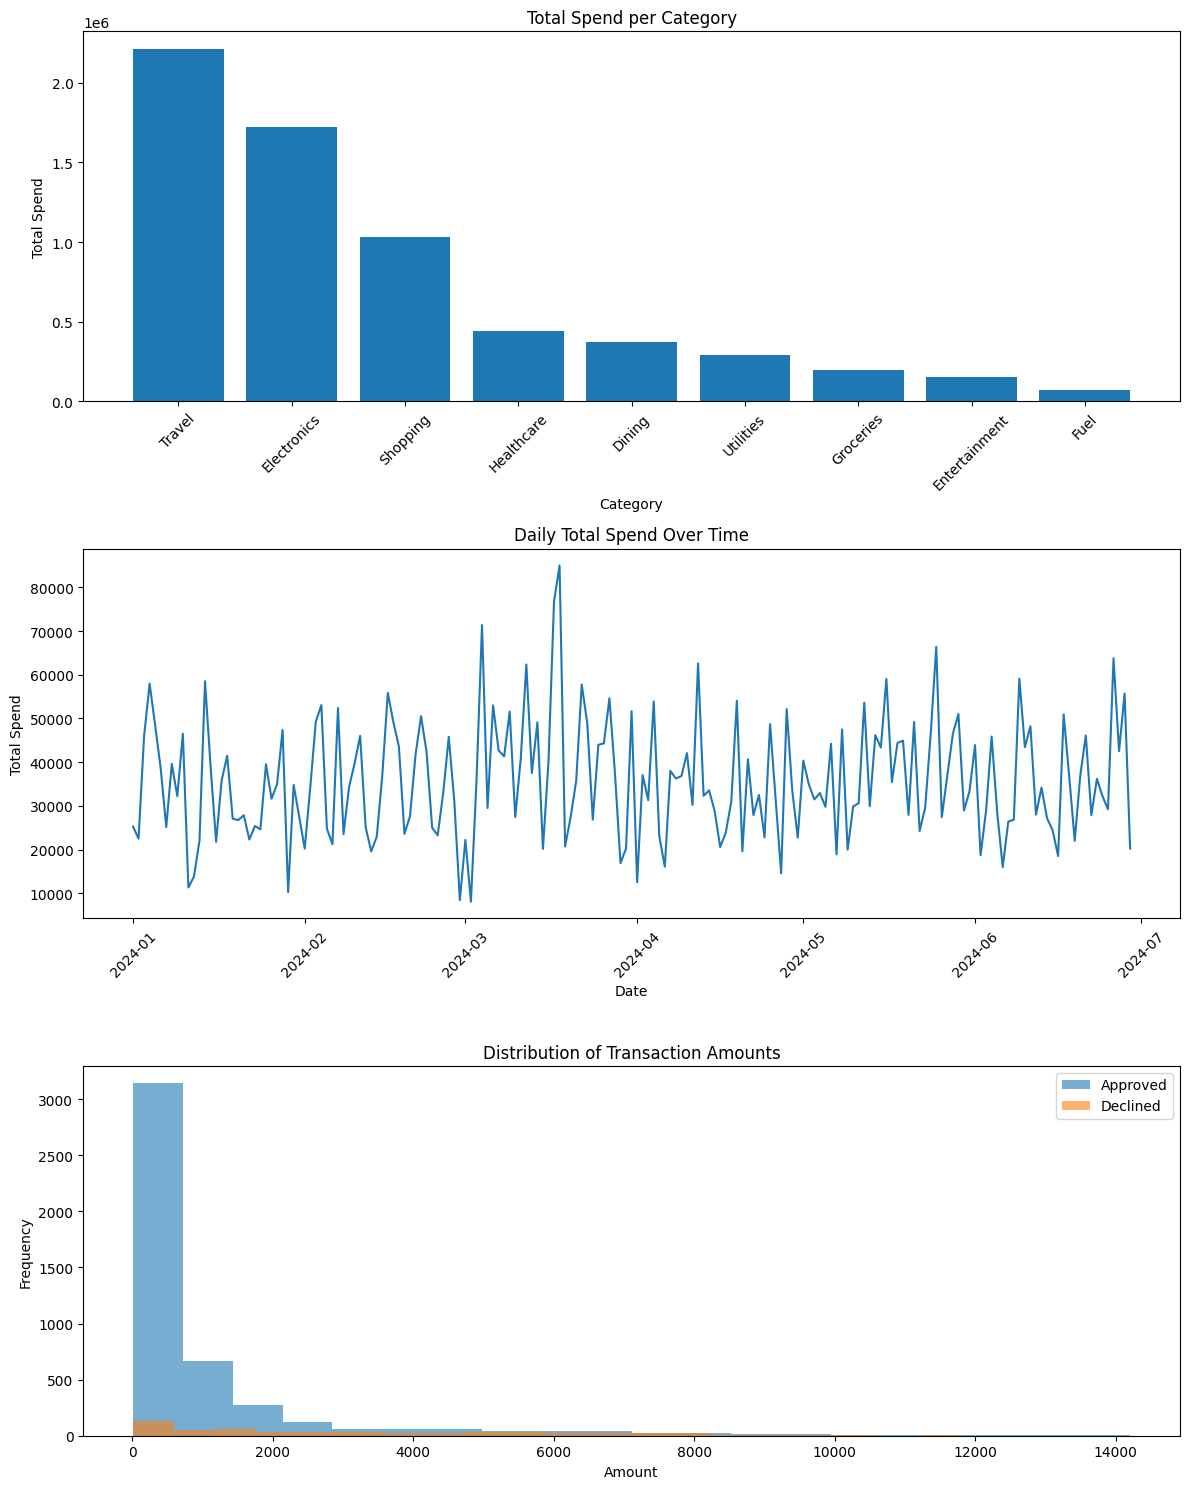

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("transactions.csv")
# Ensure datetime column is datetime type
df["datetime"] = pd.to_datetime(df["datetime"])

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 15))


# 1. Bar Chart: Total spend per category

category_spend = (
    df.groupby("category")["amount"]
      .sum()
      .sort_values(ascending=False)
)

axes[0].bar(category_spend.index, category_spend.values)
axes[0].set_title("Total Spend per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Spend")
axes[0].tick_params(axis="x", rotation=45)


# 2. Line Chart: Daily total spend
daily_spend = (
    df.groupby(df["datetime"].dt.date)["amount"]
      .sum()
)

axes[1].plot(daily_spend.index, daily_spend.values)
axes[1].set_title("Daily Total Spend Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Spend")
axes[1].tick_params(axis="x", rotation=45)


# 3. Histogram: Approved vs Declined
approved = df[df["status"] == "approved"]["amount"]
declined = df[df["status"] == "declined"]["amount"]

axes[2].hist(approved, bins=20, alpha=0.6, label="Approved")
axes[2].hist(declined, bins=20, alpha=0.6, label="Declined")

axes[2].set_title("Distribution of Transaction Amounts")
axes[2].set_xlabel("Amount")
axes[2].set_ylabel("Frequency")
axes[2].legend()

# Layout
plt.tight_layout()
plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.


In [ ]:
# your code here